# Predictive Modeling for Used Car Pricing
**Author:** Umer Zaheer Lodhi

**Objective:** To develop a robust machine learning pipeline capable of predicting the market value of used vehicles. This analysis encompasses data preprocessing, feature engineering of categorical specifications, and the training of a Random Forest regression model to capture non-linear pricing dynamics.

## Step 1: Environment Setup 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## Step 2: Data Inspection

In [36]:

df_car = pd.read_csv('car data.csv')

print(f"Dataset Shape: {df_car.shape}\n")
display(df_car.head())

print("\nDataset Info:")
df_car.info()

print("\nStatistical Summary:")
display(df_car.describe())

Dataset Shape: (301, 9)



,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Statistical Summary:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Step 3: Exploratory Data Analysis (EDA)


ValueError: Could not interpret value `Seller_Type` for `x`. An entry with this name does not appear in `data`.

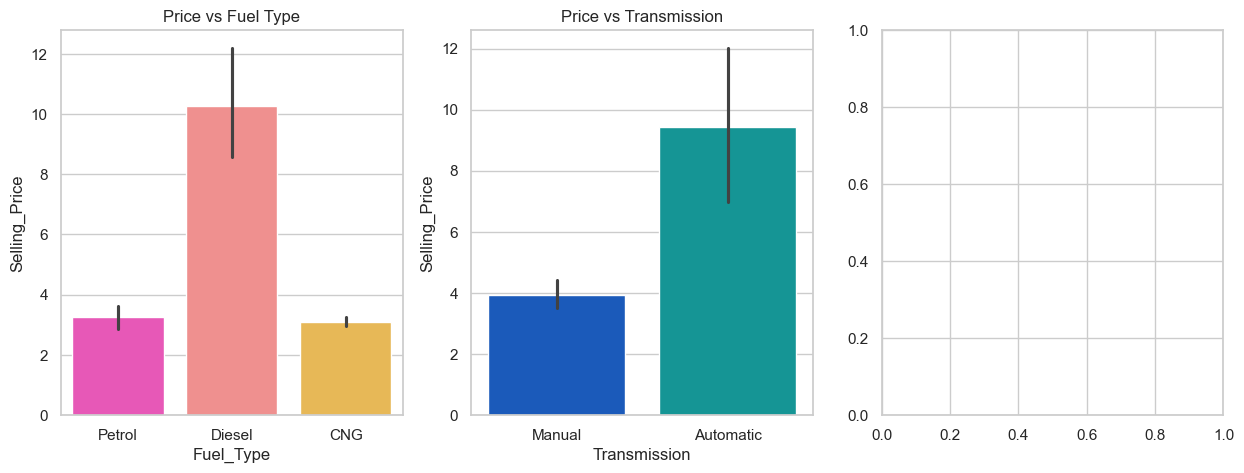

In [64]:
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(ax=axes[0], x='Fuel_Type', y='Selling_Price', data=df_car, hue='Fuel_Type', palette='spring', legend=False)
axes[0].set_title('Price vs Fuel Type')

sns.barplot(ax=axes[1], x='Transmission', y='Selling_Price', data=df_car, hue='Transmission', palette='winter', legend=False)
axes[1].set_title('Price vs Transmission')

sns.barplot(ax=axes[2], x='Seller_Type', y='Selling_Price', data=df_car, hue='Seller_Type', palette='summer', legend=False)
axes[2].set_title('Price vs Seller Type')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
num_cols = df_car.select_dtypes(include=[np.number])
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Step 4: Feature Engineering

In [62]:
# Hardcoding 2026 as the baseline year for vehicle age assumption
if 'Year' in df_car.columns:
    df_car['Car_Age'] = 2026 - df_car['Year']

df_car.drop(['Car_Name', 'Year'], axis=1, inplace=True, errors='ignore')

df_car_encoded = pd.get_dummies(df_car, drop_first=True)

# Casting booleans to ints to prevent scikit-learn type validation errors
for col in df_car_encoded.select_dtypes(include=['bool']).columns:
    df_car_encoded[col] = df_car_encoded[col].astype(int)

print(f"Processed dataset shape: {df_car_encoded.shape}\n")
display(df_car_encoded.head(4))

Processed dataset shape: (301, 9)



,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,0,1,0,1
1,4.75,9.54,43000,0,13,1,0,0,1
2,7.25,9.85,6900,0,9,0,1,0,1
3,2.85,4.15,5200,0,15,0,1,0,1


## Step 5: Model Training & Evaluation.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

X = df_car_encoded.drop('Selling_Price', axis=1)
y = df_car_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

r2 = metrics.r2_score(y_test, predictions)
mae = metrics.mean_absolute_error(y_test, predictions)

print("Model Performance:")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Model Performance:
R-squared (R2): 0.9595
Mean Absolute Error (MAE): 0.6369


## Step 6: Visualizing Model Accuracy.

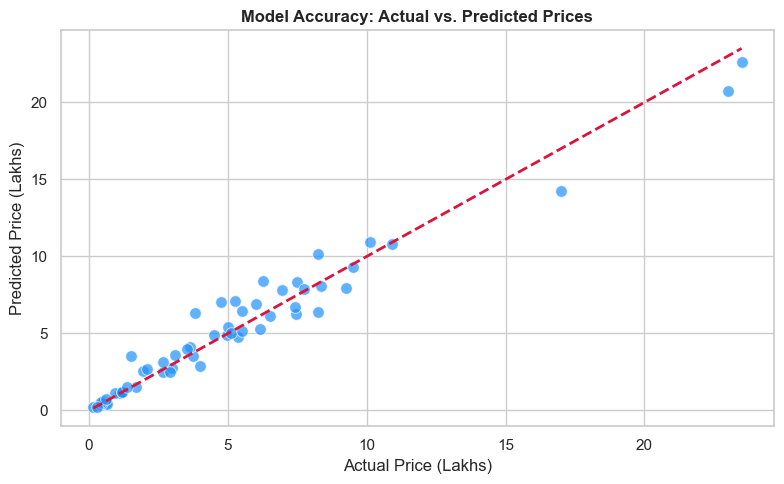

In [58]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=predictions, alpha=0.7, color='dodgerblue', edgecolor='w', s=70)

max_val = max(y_test.max(), predictions.max())
min_val = min(y_test.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2)

plt.title('Model Accuracy: Actual vs. Predicted Prices', fontweight='bold')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')

plt.tight_layout()
plt.show()